In [5]:
# This extension reloads all imports before running each cell
%load_ext autoreload
%autoreload 2

In [6]:
from slam_project.io import load_data as ld
from slam_project.mapping import mapper as mp
import matplotlib.pyplot as plt

lidar = ld.get_lidar('./data/Hokuyo20')

print(lidar[0]["scan"])

[3.375      3.375      3.38199997 ... 4.90999985 4.90999985 4.90999985]


In [7]:
print(lidar[0]["angle"])

[[-2.35619449]
 [-2.35183117]
 [-2.34746784]
 ...
 [ 2.34746784]
 [ 2.35183117]
 [ 2.35619449]]


In [8]:
import numpy as np
end = lidar[0]["angle"][0]
print(end * 180 / np.pi)

[-135.]


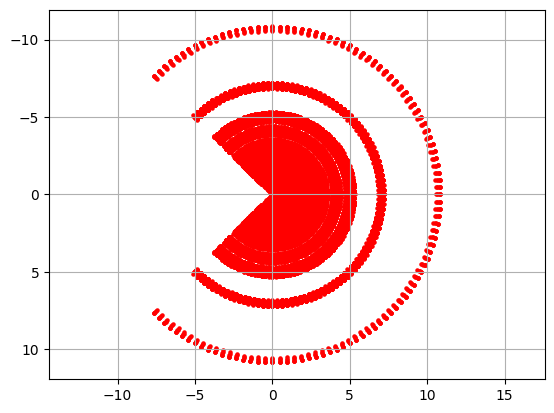

In [12]:
fig, ax = plt.subplots(1,1)
mp.lidar2gridmap(ax, lidar[0])

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


0.0010000000474974513 10.847999572753906


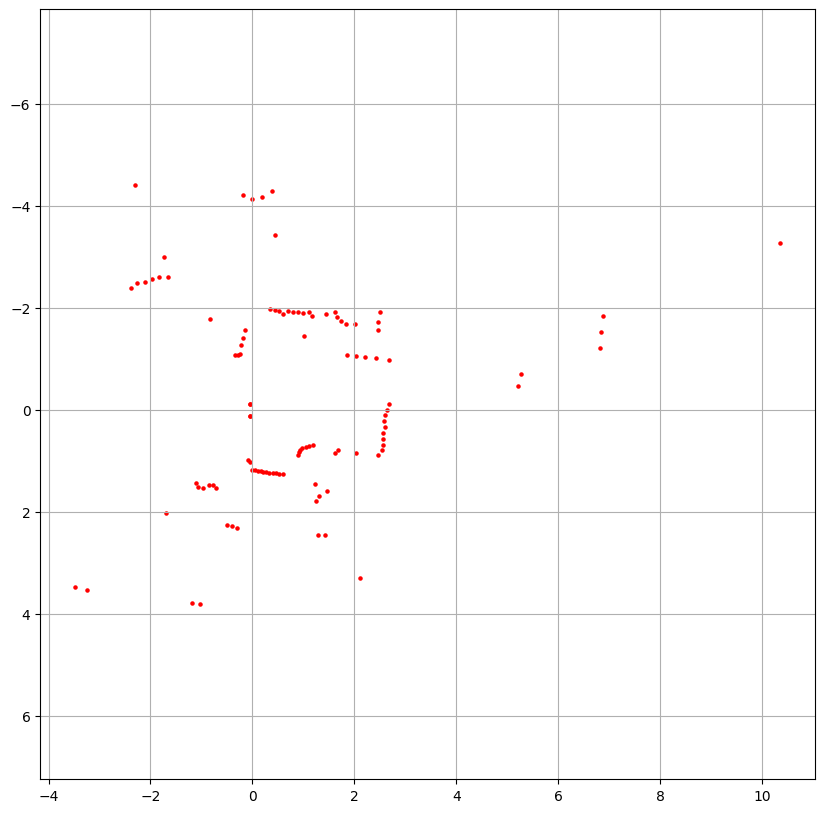

In [31]:
from slam_project.io import load_data as ld
from slam_project.mapping import mapper as mp
import matplotlib.pyplot as plt

lidar = ld.get_lidar('./data/Hokuyo20')

fig, ax = plt.subplots(1,1,figsize=(10,10))

mp.lidar2gridmap(ax, lidar[0])


In [30]:
lidar_snapshot = lidar[0]
print(lidar_snapshot)

{'t': np.float64(1298445274.550587), 'scan': array([3.375     , 3.375     , 3.38199997, ..., 4.90999985, 4.90999985,
       4.90999985], shape=(1081,)), 'angle': array([[-2.35619449],
       [-2.35183117],
       [-2.34746784],
       ...,
       [ 2.34746784],
       [ 2.35183117],
       [ 2.35619449]], shape=(1081, 1))}


In [46]:
lidar[1]['t']/(10**9)

np.float64(1.298445274574476)

In [44]:
from slam_project.localization import odometry as od
theta = od.get_robot_rotation("./data/Encoders20")
_, _, _, _, t = ld.get_encoder("./data/Encoders20")
len(theta)
print(t)

[1.29844527e+09 1.29844527e+09 1.29844527e+09 ... 1.29844540e+09
 1.29844540e+09 1.29844540e+09]


In [48]:
t

array([1.29844527e+09, 1.29844527e+09, 1.29844527e+09, ...,
       1.29844540e+09, 1.29844540e+09, 1.29844540e+09], shape=(4956,))

In [ ]:
X, Y, theta, t = od.parse_encoders("./data/Encoders20")
mp.global_lidar2gridmap_coords(lidar, X, Y, theta, t)



(array([-2.38648539, -2.3760497 , -2.37047511, ..., -3.44146438,
        -3.45671219, -3.47189419], shape=(1081,)),
 array([-2.38648539, -2.39687564, -2.412213  , ...,  3.5020596 ,
         3.48701009,  3.47189419], shape=(1081,)))